In [2]:
!pip install pandas numpy scikit-learn

In [10]:
import pandas as pd
import numpy as np

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [13]:
df = pd.read_csv("netflix.zip")

In [14]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [15]:
df.tail()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."
8806,s8807,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,"March 2, 2019",2015,TV-14,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...


In [16]:
df.shape

(8807, 12)

In [17]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='str')

In [18]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [19]:
df = df[['show_id', 'type', 'title', 'director', 'cast',
         'country', 'release_year', 'rating', 'duration',
         'listed_in', 'description']]

In [20]:
df.head()

,show_id,type,title,director,cast,country,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [21]:
columns = ['director', 'cast', 'country', 'rating', 'duration', 'listed_in', 'description']

for column in columns:
    df[column] = df[column].fillna('')

In [22]:
df.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

In [23]:
df['combined_features'] = (
    df['type'] + ' ' +
    df['director'] + ' ' +
    df['cast'] + ' ' +
    df['country'] + ' ' +
    df['listed_in'] + ' ' +
    df['description']
)

In [24]:
df[['title', 'combined_features']].head()

,title,combined_features
0,Dick Johnson Is Dead,Movie Kirsten Johnson United States Documenta...
1,Blood & Water,"TV Show Ama Qamata, Khosi Ngema, Gail Mabalan..."
2,Ganglands,"TV Show Julien Leclercq Sami Bouajila, Tracy G..."
3,Jailbirds New Orleans,"TV Show Docuseries, Reality TV Feuds, flirt..."
4,Kota Factory,"TV Show Mayur More, Jitendra Kumar, Ranjan Ra..."


In [26]:
tfidf = TfidfVectorizer(stop_words='english')

In [27]:
tfidf_matrix = tfidf.fit_transform(df['combined_features'])

In [28]:
tfidf_matrix.shape

(8807, 49971)

In [29]:
similarity = cosine_similarity(tfidf_matrix)

In [30]:
similarity.shape

(8807, 8807)

In [31]:
indices = pd.Series(df.index, index=df['title']).drop_duplicates()

In [32]:
def recommend(title, num_recommendations=10):

    # Check whether the title exists
    if title not in indices:
        return "Title not found in Netflix dataset."

    # Get the index of the selected title
    idx = indices[title]

    # Get similarity scores
    similarity_scores = list(enumerate(similarity[idx]))

    # Sort titles by similarity
    similarity_scores = sorted(
        similarity_scores,
        key=lambda x: x[1],
        reverse=True
    )

    # Remove the selected title itself
    similarity_scores = similarity_scores[1:num_recommendations + 1]

    # Get the indexes
    movie_indices = [i[0] for i in similarity_scores]

    # Return recommendations
    recommendations = df.iloc[movie_indices][
        ['title', 'type', 'release_year', 'listed_in']
    ]

    return recommendations

In [33]:
recommend("Stranger Things")

,title,type,release_year,listed_in
5200,Beyond Stranger Things,TV Show,2017,"Stand-Up Comedy & Talk Shows, TV Mysteries, TV..."
1127,Prank Encounters,TV Show,2021,"Reality TV, TV Comedies, TV Horror"
2190,The Umbrella Academy,TV Show,2020,"TV Action & Adventure, TV Mysteries, TV Sci-Fi..."
6167,Anjaan: Special Crimes Unit,TV Show,2018,"International TV Shows, TV Horror, TV Mysteries"
4809,Kiss Me First,TV Show,2018,"British TV Shows, Crime TV Shows, Internationa..."
8803,Zombie Dumb,TV Show,2018,"Kids' TV, Korean TV Shows, TV Comedies"
880,Haunted,TV Show,2021,"Reality TV, TV Horror, TV Thrillers"
2600,Good Witch,TV Show,2019,"TV Dramas, TV Sci-Fi & Fantasy"
241,Manifest,TV Show,2021,"TV Dramas, TV Mysteries, TV Sci-Fi & Fantasy"
1978,Ratched,TV Show,2020,"TV Dramas, TV Horror, TV Mysteries"


In [34]:
recommend("Stranger Things", 5)

,title,type,release_year,listed_in
5200,Beyond Stranger Things,TV Show,2017,"Stand-Up Comedy & Talk Shows, TV Mysteries, TV..."
1127,Prank Encounters,TV Show,2021,"Reality TV, TV Comedies, TV Horror"
2190,The Umbrella Academy,TV Show,2020,"TV Action & Adventure, TV Mysteries, TV Sci-Fi..."
6167,Anjaan: Special Crimes Unit,TV Show,2018,"International TV Shows, TV Horror, TV Mysteries"
4809,Kiss Me First,TV Show,2018,"British TV Shows, Crime TV Shows, Internationa..."


In [35]:
recommend("stranger things")

'Title not found in Netflix dataset.'

In [36]:
def find_title(title):

    matches = df[df['title'].str.lower().str.contains(title.lower(), na=False)]

    if len(matches) == 0:
        print("No title found.")
    else:
        print(matches[['title', 'type', 'release_year']].to_string(index=False))

In [37]:
find_title("stranger")

                       title    type  release_year
               The Strangers   Movie          2008
The Strangers: Prey at Night   Movie          2018
       Two Distant Strangers   Movie          2021
                    Stranger TV Show          2020
         Strangers from Hell TV Show          2019
                THE STRANGER TV Show          2020
             Stranger Things TV Show          2019
      Beyond Stranger Things TV Show          2017
            Perfect Stranger   Movie          2007
       Stranger than Fiction   Movie          2006


In [38]:
def netflix_recommendation():

    title = input("Enter a Netflix movie or TV show: ")

    matches = df[
        df['title'].str.lower() == title.lower()
    ]

    if matches.empty:

        print("\nTitle not found.")
        print("Try checking the spelling or enter another title.")

        return

    actual_title = matches.iloc[0]['title']

    print("\nRecommendations for:", actual_title)
    print("-" * 50)

    recommendations = recommend(actual_title, 10)

    print(recommendations.to_string(index=False))

In [40]:
netflix_recommendation()

Enter a Netflix movie or TV show:  stranger things



Recommendations for: Stranger Things
--------------------------------------------------
                      title    type  release_year                                                       listed_in
     Beyond Stranger Things TV Show          2017 Stand-Up Comedy & Talk Shows, TV Mysteries, TV Sci-Fi & Fantasy
           Prank Encounters TV Show          2021                              Reality TV, TV Comedies, TV Horror
       The Umbrella Academy TV Show          2020        TV Action & Adventure, TV Mysteries, TV Sci-Fi & Fantasy
Anjaan: Special Crimes Unit TV Show          2018                 International TV Shows, TV Horror, TV Mysteries
              Kiss Me First TV Show          2018        British TV Shows, Crime TV Shows, International TV Shows
                Zombie Dumb TV Show          2018                          Kids' TV, Korean TV Shows, TV Comedies
                    Haunted TV Show          2021                             Reality TV, TV Horror, TV Thrillers

### ADDING A BETTER TITLE SEARCH

In [41]:
def search_and_recommend():

    user_input = input("Enter movie/show name: ")

    matches = df[
        df['title'].str.lower().str.contains(
            user_input.lower(),
            na=False
        )
    ]

    if matches.empty:
        print("\nNo matching title found.")
        return

    if len(matches) > 1:

        print("\nMultiple titles found:\n")

        print(
            matches[['title', 'type', 'release_year']]
            .to_string(index=False)
        )

        print("\nPlease enter the exact title.")

        return

    title = matches.iloc[0]['title']

    print("\nSelected:", title)
    print("\nRecommended titles:\n")

    recommendations = recommend(title, 10)

    print(recommendations.to_string(index=False))

In [53]:
search_and_recommend()

Enter movie/show name:  Kota Factory



Selected: Kota Factory

Recommended titles:

               title    type  release_year                                                listed_in
     Yeh Meri Family TV Show          2018                      International TV Shows, TV Comedies
        Girls Hostel TV Show          2018           International TV Shows, TV Comedies, TV Dramas
       Chaman Bahaar   Movie          2020                   Comedies, Dramas, International Movies
              Betaal TV Show          2020 International TV Shows, TV Action & Adventure, TV Horror
   Engineering Girls TV Show          2018                      International TV Shows, TV Comedies
The Creative Indians TV Show          2020                       Docuseries, International TV Shows
       Little Things TV Show          2019   International TV Shows, Romantic TV Shows, TV Comedies
Single Ladies Senior TV Show          2018     International TV Shows, Romantic TV Shows, TV Dramas
      Guru Aur Bhole TV Show          2018            

### DATASET STATISTICS

In [43]:
df['type'].value_counts()

type
Movie      6131
TV Show    2676
Name: count, dtype: int64

In [44]:
df['release_year'].value_counts().sort_index()

release_year
1925       1
1942       2
1943       3
1944       3
1945       4
        ... 
2017    1032
2018    1147
2019    1030
2020     953
2021     592
Name: count, Length: 74, dtype: int64

In [45]:
df['listed_in'].value_counts().head(10)

listed_in
Dramas, International Movies                        362
Documentaries                                       359
Stand-Up Comedy                                     334
Comedies, Dramas, International Movies              274
Dramas, Independent Movies, International Movies    252
Kids' TV                                            220
Children & Family Movies                            215
Children & Family Movies, Comedies                  201
Documentaries, International Movies                 186
Dramas, International Movies, Romantic Movies       180
Name: count, dtype: int64

In [46]:
df['listed_in'].value_counts().head(10)

listed_in
Dramas, International Movies                        362
Documentaries                                       359
Stand-Up Comedy                                     334
Comedies, Dramas, International Movies              274
Dramas, Independent Movies, International Movies    252
Kids' TV                                            220
Children & Family Movies                            215
Children & Family Movies, Comedies                  201
Documentaries, International Movies                 186
Dramas, International Movies, Romantic Movies       180
Name: count, dtype: int64

### SIMPLE GRAPH

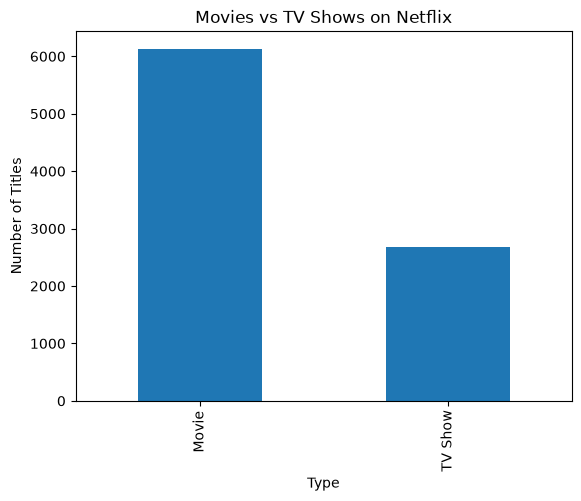

In [47]:
import matplotlib.pyplot as plt

df['type'].value_counts().plot(kind='bar')

plt.title("Movies vs TV Shows on Netflix")
plt.xlabel("Type")
plt.ylabel("Number of Titles")

plt.show()

In [48]:
countries = df['country'].str.split(',').explode()

countries = countries.str.strip()

countries.value_counts().head(10)

country
United States     3690
India             1046
                   838
United Kingdom     806
Canada             445
France             393
Japan              318
Spain              232
South Korea        231
Germany            226
Name: count, dtype: int64

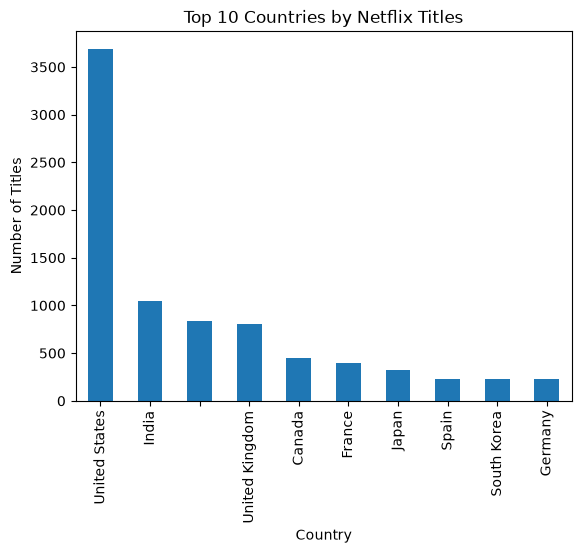

In [49]:
countries.value_counts().head(10).plot(kind='bar')

plt.title("Top 10 Countries by Netflix Titles")
plt.xlabel("Country")
plt.ylabel("Number of Titles")

plt.show()